<a href="https://www.kaggle.com/code/lalit7881/data-driven-student-dropout-forecasting?scriptVersionId=299403278" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-dropout-prediction-dataset/student_dropout_dataset_v3.csv


## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/student-dropout-prediction-dataset/student_dropout_dataset_v3.csv')

In [3]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [5]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [6]:
df.describe().loc[['min', 'max']]

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
min,1.0,17.0,25000.0,0.50,38.2,0.0,5.0,1.0,0.0,0.0,0.0,0.0
max,10000.0,29.6,316601.0,8.98,100.0,8.0,74.9,10.0,4.0,4.0,4.0,1.0


In [7]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Student_ID                 int64
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

In [10]:
df.shape

(10000, 19)

In [11]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

In [12]:
df.nunique()

Student_ID               10000
Age                        115
Gender                       2
Family_Income             5438
Internet_Access              2
Study_Hours_per_Day        702
Attendance_Rate            444
Assignment_Delay_Days        9
Travel_Time_Minutes        589
Part_Time_Job                2
Scholarship                  2
Stress_Index                91
GPA                        401
Semester_GPA               401
CGPA                       401
Semester                     4
Department                   5
Parental_Education           4
Dropout                      2
dtype: int64

In [13]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric Columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical Columns ({len(categorical_cols)}): {categorical_cols}")


Numeric Columns (12): ['Student_ID', 'Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Dropout']

Categorical Columns (7): ['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']


In [14]:
print("NUMERIC COLUMNS STATISTICS:")
df[numeric_cols].describe().round(2)

NUMERIC COLUMNS STATISTICS:


,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00,10000.00,9500.00,9500.00,10000.00,10000.00,10000.00,9500.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,21.03,38377.25,4.01,81.74,1.80,30.18,5.51,2.31,2.30,2.30,0.24
std,2886.90,2.14,20496.23,1.30,8.22,1.34,11.92,1.77,1.06,1.07,1.07,0.42
min,1.00,17.00,25000.00,0.50,38.20,0.00,5.00,1.00,0.00,0.00,0.00,0.00
25%,2500.75,19.50,25000.00,3.16,76.40,1.00,21.90,4.30,1.55,1.52,1.52,0.00
50%,5000.50,21.00,29740.50,4.00,81.80,2.00,30.20,5.50,2.35,2.35,2.35,0.00
75%,7500.25,22.50,44520.00,4.87,87.30,3.00,38.40,6.70,3.12,3.15,3.15,0.00
max,10000.00,29.60,316601.00,8.98,100.00,8.00,74.90,10.00,4.00,4.00,4.00,1.00


In [15]:
# Target variable distribution
dropout_counts = df['Dropout'].value_counts()
dropout_pct = df['Dropout'].value_counts(normalize=True) * 100

print(f"Dropout Distribution:")
print(f"No Dropout (0): {dropout_counts[0]} ({dropout_pct[0]:.2f}%)")
print(f"Dropout (1): {dropout_counts[1]} ({dropout_pct[1]:.2f}%)")

Dropout Distribution:
No Dropout (0): 7646 (76.46%)
Dropout (1): 2354 (23.54%)


In [16]:
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts().head(10))


GENDER:
Gender
Female    5011
Male      4989
Name: count, dtype: int64

INTERNET_ACCESS:
Internet_Access
Yes    8769
No     1231
Name: count, dtype: int64

PART_TIME_JOB:
Part_Time_Job
No     5996
Yes    4004
Name: count, dtype: int64

SCHOLARSHIP:
Scholarship
No     6489
Yes    3511
Name: count, dtype: int64

SEMESTER:
Semester
Year 4    2536
Year 3    2521
Year 2    2488
Year 1    2455
Name: count, dtype: int64

DEPARTMENT:
Department
Science        2061
Arts           2026
Business       2002
CS             1974
Engineering    1937
Name: count, dtype: int64

PARENTAL_EDUCATION:
Parental_Education
Bachelor       3949
High School    3072
Master         2003
PhD             465
Name: count, dtype: int64


## EDA

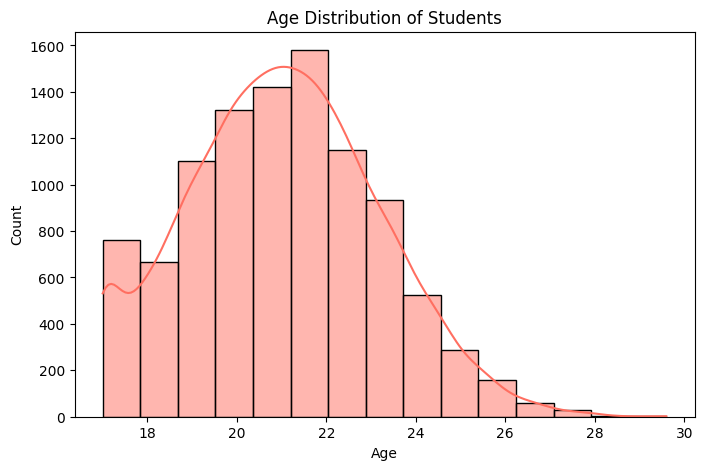

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15, kde=True, color='#FF6F61')
plt.title("Age Distribution of Students")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

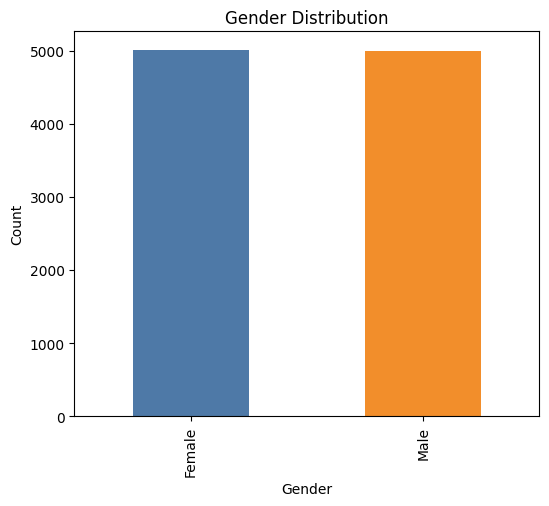

In [18]:
plt.figure(figsize=(6,5))
df['Gender'].value_counts().plot(
    kind='bar',
    color=['#4E79A7', '#F28E2B']
)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

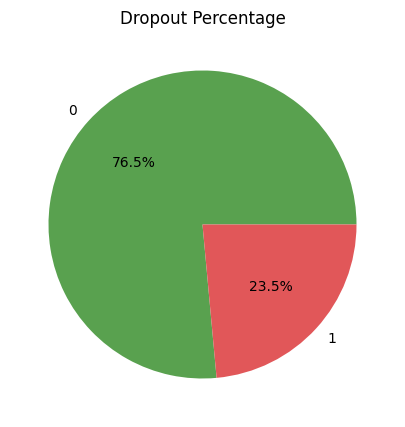

In [19]:
plt.figure(figsize=(6,5))
df['Dropout'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#59A14F', '#E15759']
)
plt.title("Dropout Percentage")
plt.ylabel("")
plt.show()

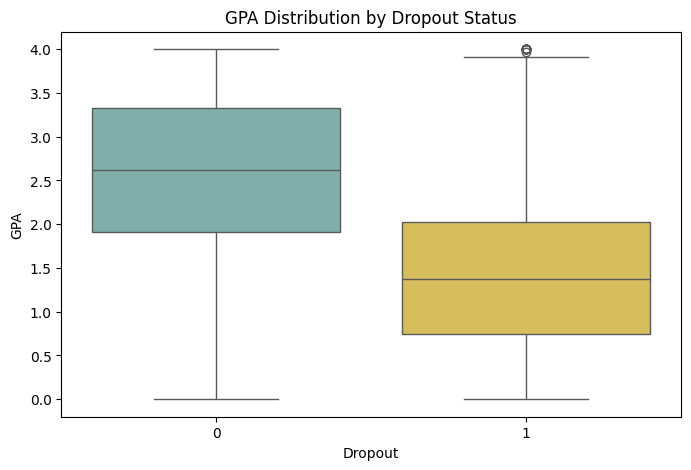

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Dropout', y='GPA', data=df, palette=['#76B7B2','#EDC948'])
plt.title("GPA Distribution by Dropout Status")
plt.show()

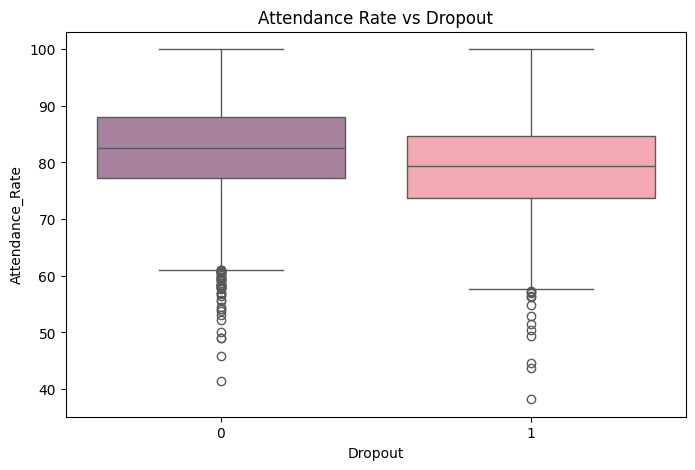

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Dropout', y='Attendance_Rate', data=df,
            palette=['#AF7AA1','#FF9DA7'])
plt.title("Attendance Rate vs Dropout")
plt.show()

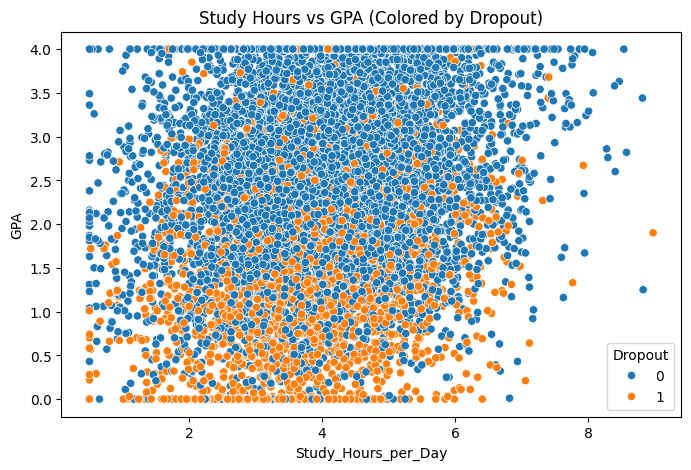

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Study_Hours_per_Day',
    y='GPA',
    hue='Dropout',
    data=df,
    palette=['#1F77B4','#FF7F0E']
)
plt.title("Study Hours vs GPA (Colored by Dropout)")
plt.show()

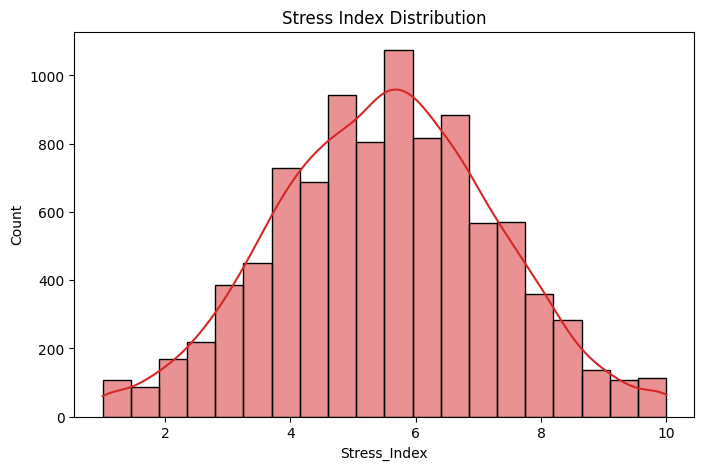

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['Stress_Index'], bins=20, color='#D62728', kde=True)
plt.title("Stress Index Distribution")
plt.show()

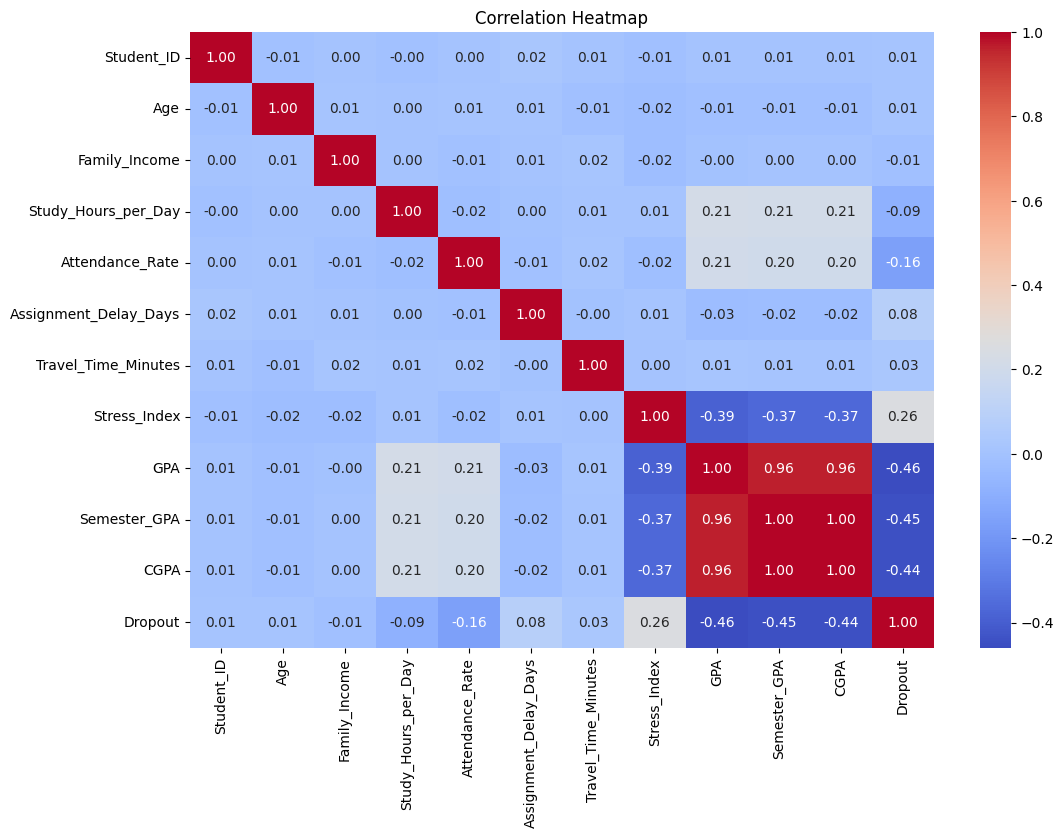

In [24]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

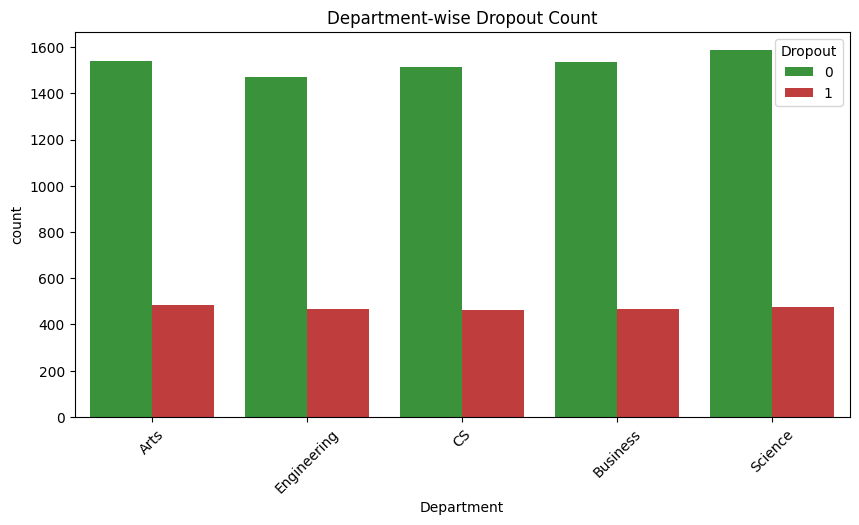

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='Department',
    hue='Dropout',
    data=df,
    palette=['#2CA02C','#D62728']
)
plt.xticks(rotation=45)
plt.title("Department-wise Dropout Count")
plt.show()

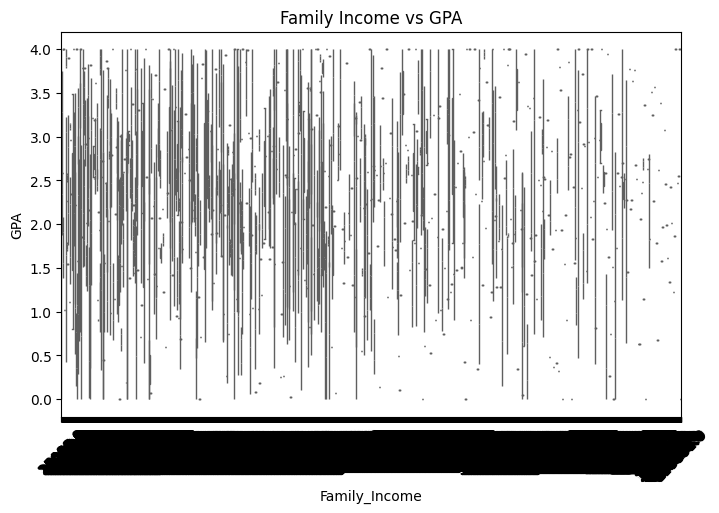

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Family_Income',
    y='GPA',
    data=df,
    palette='Set3'
)
plt.title("Family Income vs GPA")
plt.xticks(rotation=45)
plt.show()

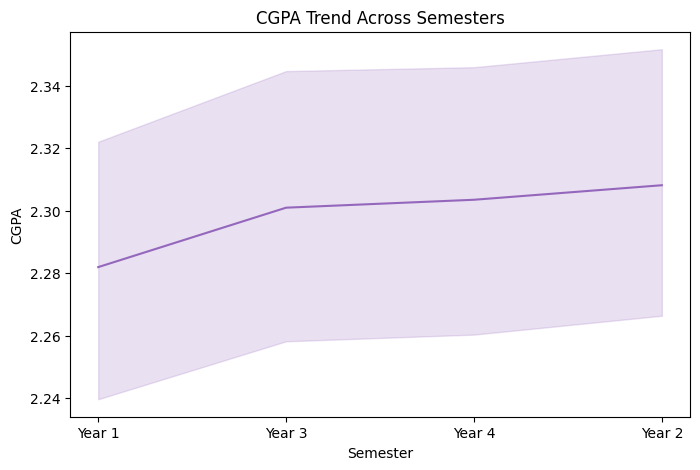

In [27]:
plt.figure(figsize=(8,5))
sns.lineplot(
    x='Semester',
    y='CGPA',
    data=df,
    color='#9467BD'
)
plt.title("CGPA Trend Across Semesters")
plt.show()

## Feature engg

Summary Statistics by Dropout:

           Age              Family_Income                     \
          mean median   std          mean   median       std   
Dropout                                                        
0        21.02   21.0  2.13      38503.91  29806.0  20425.27   
1        21.06   21.1  2.17      37966.97  29394.0  20723.71   

        Study_Hours_per_Day              Attendance_Rate  ... Stress_Index  \
                       mean median   std            mean  ...          std   
Dropout                                                   ...                
0                      4.08   4.08  1.30           82.48  ...         1.72   
1                      3.81   3.80  1.27           79.31  ...         1.67   

          GPA              Semester_GPA               CGPA               
         mean median   std         mean median   std  mean median   std  
Dropout                                                                  
0        2.58   2.62  0.95        

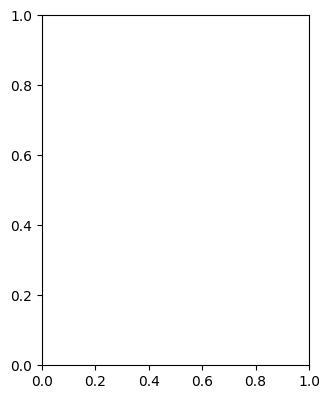

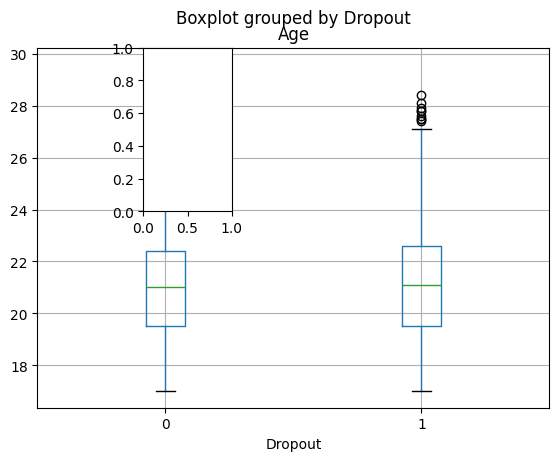

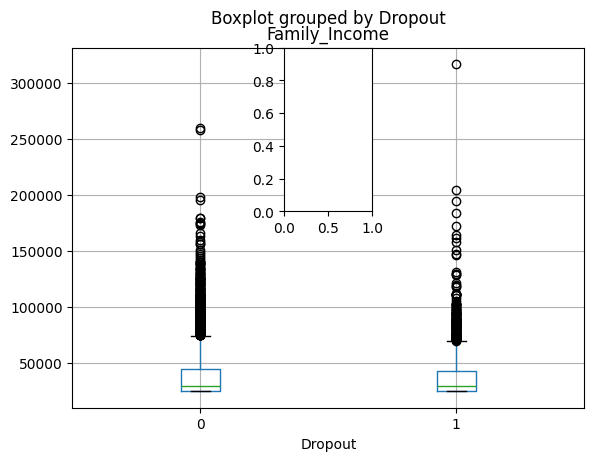

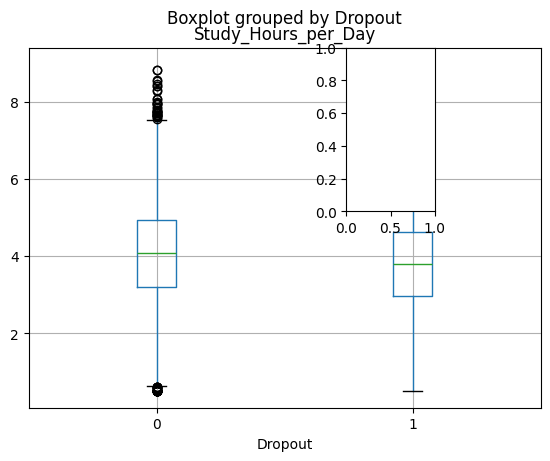

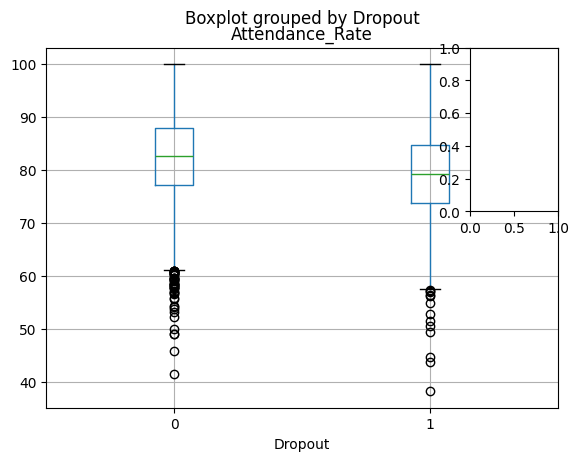

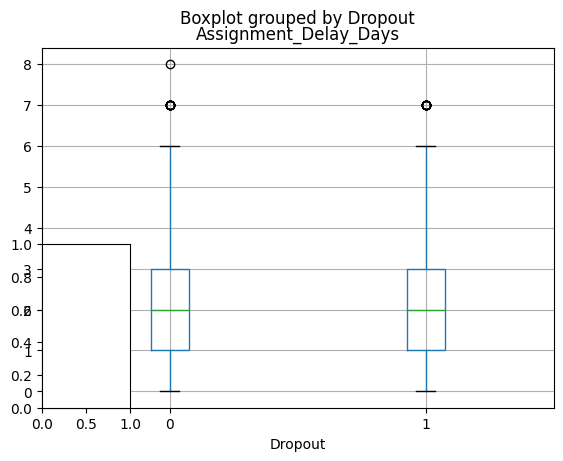

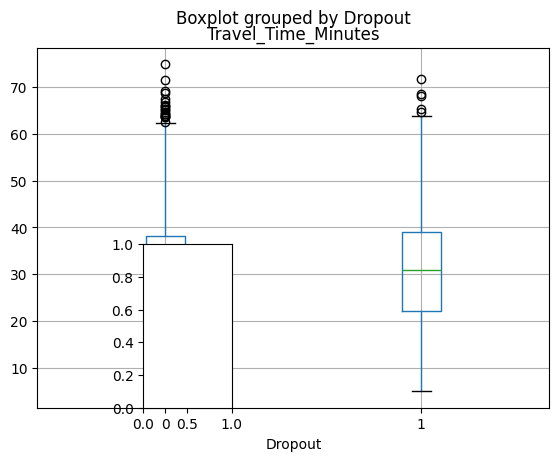

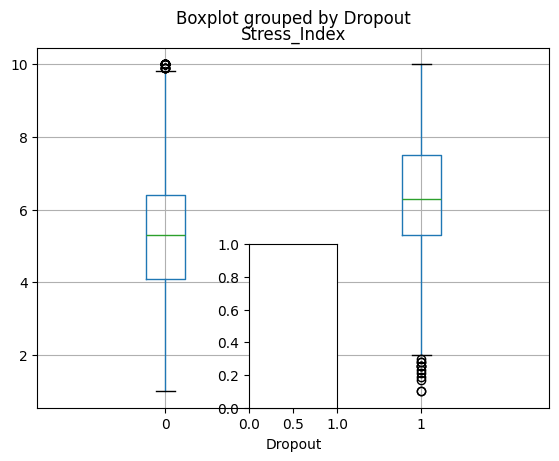

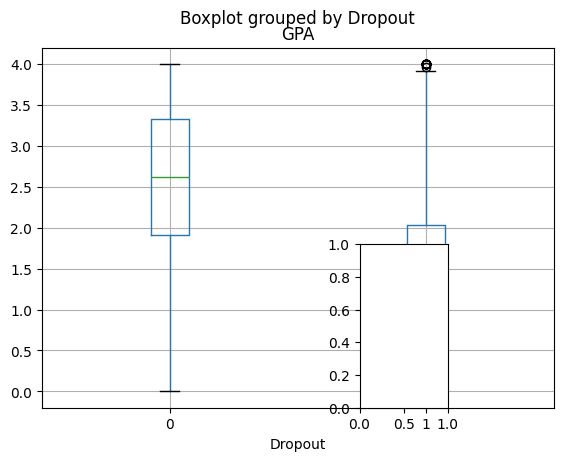

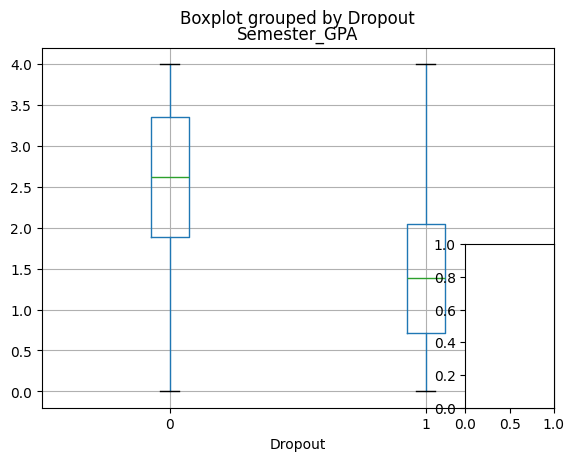

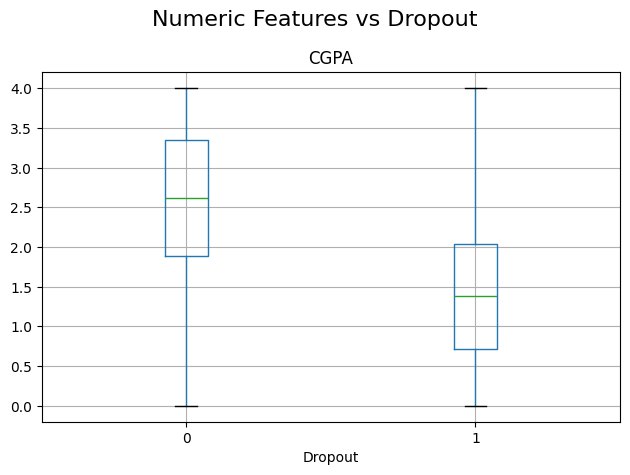

In [28]:
numeric_features = [
    'Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
    'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index',
    'GPA', 'Semester_GPA', 'CGPA'
]

# Print Mean, Median, Std grouped by Dropout
print("Summary Statistics by Dropout:\n")
print(df.groupby('Dropout')[numeric_features].agg(['mean', 'median', 'std']).round(2))

# Create boxplots (simple loop)
plt.figure(figsize=(20,10))

for i, feature in enumerate(numeric_features, 1):
    plt.subplot(2, 5, i)
    df.boxplot(column=feature, by='Dropout')
    plt.title(feature)
    plt.xlabel('Dropout')
    plt.ylabel('')

plt.suptitle("Numeric Features vs Dropout", fontsize=16)
plt.tight_layout()
plt.show()

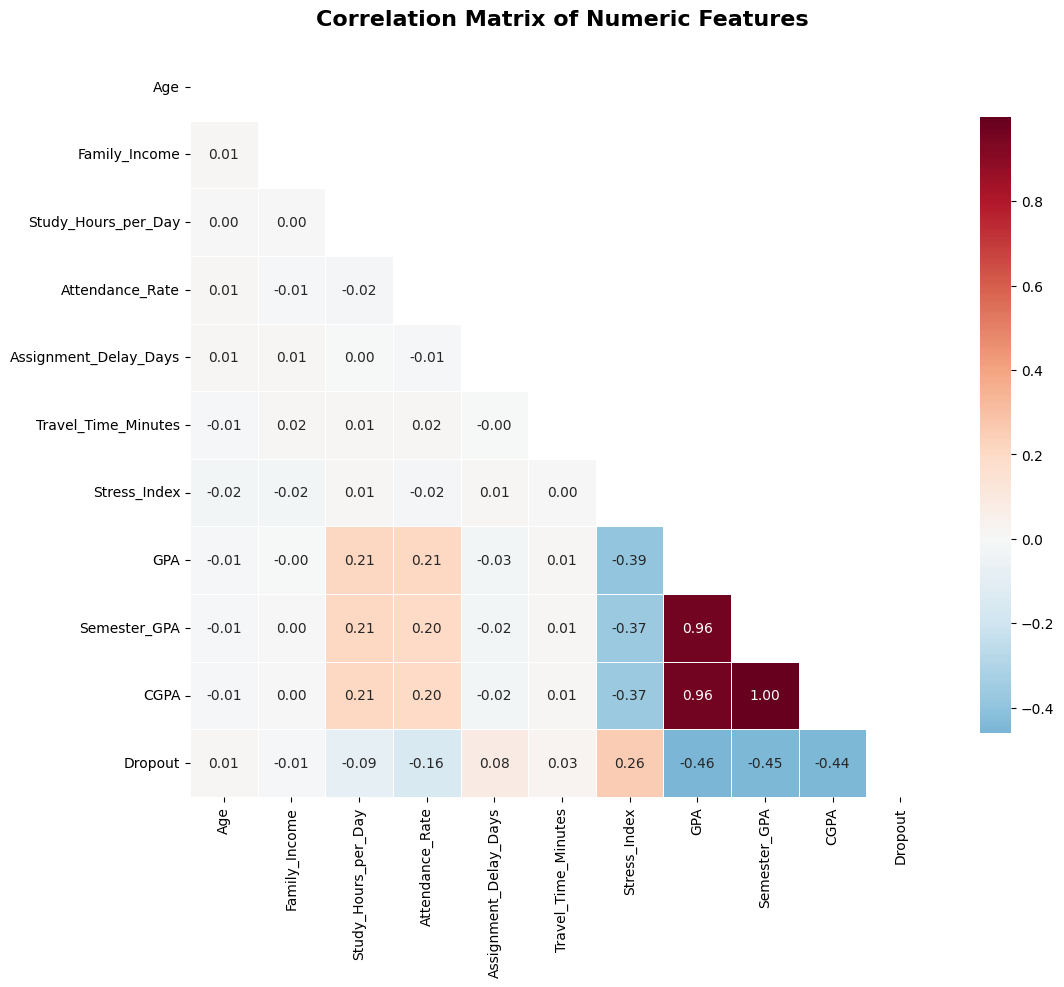


Correlations with Dropout (sorted by absolute value):
GPA                     -0.460352
Semester_GPA            -0.445396
CGPA                    -0.444807
Stress_Index             0.255648
Attendance_Rate         -0.163539
Study_Hours_per_Day     -0.089376
Assignment_Delay_Days    0.082327
Travel_Time_Minutes      0.028080
Family_Income           -0.011123
Age                      0.007585
Name: Dropout, dtype: float64


In [29]:
numeric_df = df[numeric_features + ['Dropout']].copy()
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.show()

# Correlations with target
print("\nCorrelations with Dropout (sorted by absolute value):")
target_corr = correlation_matrix['Dropout'].drop('Dropout').sort_values(key=abs, ascending=False)
print(target_corr)

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score

In [31]:
df = df.drop(columns=['Student_ID'])

X = df.drop('Dropout', axis=1)
y = df['Dropout']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

In [34]:
# Numeric Pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [35]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [36]:
results = {}

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"{name}: {round(accuracy*100,2)}%")

Logistic Regression: 81.55%
Decision Tree: 73.0%
Random Forest: 80.7%
Gradient Boosting: 80.5%
SVM: 80.85%
KNN: 77.8%
Naive Bayes: 77.8%


In [37]:
print("\nModel Comparison:")
for model, acc in results.items():
    print(f"{model}: {round(acc*100, 2)}%")


Model Comparison:
Logistic Regression: 81.55%
Decision Tree: 73.0%
Random Forest: 80.7%
Gradient Boosting: 80.5%
SVM: 80.85%
KNN: 77.8%
Naive Bayes: 77.8%


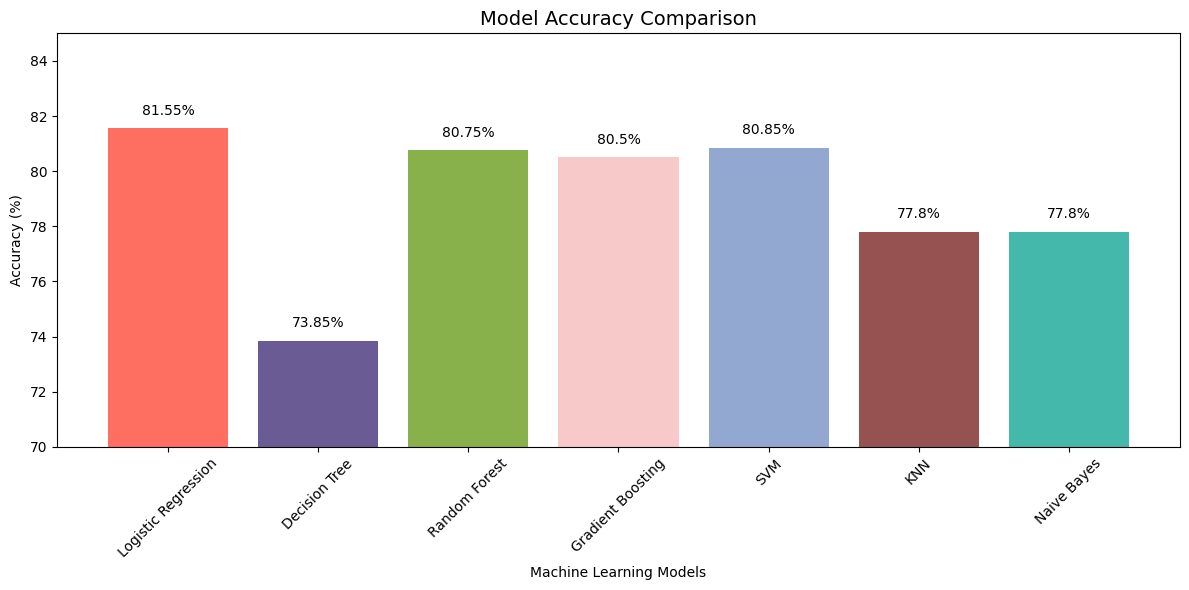

In [38]:
# Model names
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "SVM",
    "KNN",
    "Naive Bayes"
]

# Accuracy values
accuracies = [81.55, 73.85, 80.75, 80.5, 80.85, 77.8, 77.8]

# Unique colors for each bar
colors = [
    '#FF6F61',  # Red-Orange
    '#6B5B95',  # Purple
    '#88B04B',  # Green
    '#F7CAC9',  # Pink
    '#92A8D1',  # Blue
    '#955251',  # Brown
    '#45B8AC'   # Teal
]

plt.figure(figsize=(12,6))
bars = plt.bar(models, accuracies, color=colors)

# Add accuracy values on top of bars
for i in range(len(models)):
    plt.text(i, accuracies[i] + 0.5, f"{accuracies[i]}%", ha='center')

plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.ylim(70, 85)

plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!